In [31]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


In [32]:
def plot_correlation(df, cmap='RdBu_r'):
    size = len(df.columns)
    fig, ax = plt.subplots(figsize=(1.3 * size, 1. * size))
    corr = df.corr()

    im = ax.matshow(corr, cmap=cmap)
    for (i, j), z in np.ndenumerate(corr):
        ax.text(j, i, '{:0.2f}'.format(z), ha='center', va='center',
                bbox=dict(boxstyle='round', facecolor='white', edgecolor='0.3'))

    plt.xticks(range(df.select_dtypes(['number']).shape[1]), df.select_dtypes(['number']).columns, fontsize=14, rotation=90)
    plt.yticks(range(df.select_dtypes(['number']).shape[1]), df.select_dtypes(['number']).columns, fontsize=14)
    cb = plt.colorbar(im)
    ax.tick_params(labelsize=14)
    plt.show()

In [33]:
import pandas as pd

df = pd.read_csv('DASS.csv')

print(df.shape)
df.head()

(39775, 173)


,Unnamed: 0,Q1A,Q1I,Q1E,Q2A,Q2I,Q2E,Q3A,Q3I,Q3E,...,screensize,uniquenetworklocation,hand,religion,orientation,race,voted,married,familysize,major
0,0,4,28,3890,4,25,2122,2,16,1944,...,1,1,Right,Other,Heterosexual,Asian,No,Never married,2,NaN
1,1,4,2,8118,1,36,2890,2,35,4777,...,2,1,Left,Christian (Other),NaN,Other,No,Never married,4,NaN
2,2,3,7,5784,1,33,4373,4,41,3242,...,2,1,Right,Christian (Catholic),Homosexual,White,Yes,Never married,3,NaN
3,3,2,23,5081,3,11,6837,2,37,5521,...,2,1,Left,Christian (Catholic),Other,Other,No,Never married,5,biology
4,4,2,36,3215,2,13,7731,3,5,4156,...,2,2,Both,Muslim,Heterosexual,Asian,No,Never married,4,Psychology


# Validity Check


In [34]:

if 'VCL6' in df.columns:
    df = df[(df['VCL6'] == 0) & (df['VCL9'] == 0) & (df['VCL12'] == 0)]

# Filter Out Straight Liners

In [35]:
q_cols = [f'Q{i}A' for i in range(1, 43)]
df = df[df[q_cols].std(axis=1) > 0]

# Age Outliners

In [36]:
df = df[(df['age'] > 10) & (df['age'] < 100)]

# Subscale Indexes

In [37]:
dep_idx = [3, 5, 10, 13, 16, 17, 21, 24, 26, 31, 34, 37, 38, 42]
anx_idx = [2, 4, 7, 9, 15, 19, 20, 23, 25, 28, 30, 36, 40, 41]
str_idx = [1, 6, 8, 11, 12, 14, 18, 22, 27, 29, 32, 33, 35, 39]

# Calculate Scores 

In [38]:
df['Depression_Score'] = df[[f'Q{i}A' for i in dep_idx]].sum(axis=1) - len(dep_idx)
df['Anxiety_Score'] = df[[f'Q{i}A' for i in anx_idx]].sum(axis=1) - len(anx_idx)
df['Stress_Score'] = df[[f'Q{i}A' for i in str_idx]].sum(axis=1) - len(str_idx)

C:\Users\ALi\AppData\Local\Temp\ipykernel_14700\1261996734.py:1: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df['Depression_Score'] = df[[f'Q{i}A' for i in dep_idx]].sum(axis=1) - len(dep_idx)
C:\Users\ALi\AppData\Local\Temp\ipykernel_14700\1261996734.py:2: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df['Anxiety_Score'] = df[[f'Q{i}A' for i in anx_idx]].sum(axis=1) - len(anx_idx)
C:\Users\ALi\AppData\Local\Temp\ipykernel_14700\1261996734.py:3: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of

In [39]:
if 'TIPI1' in df.columns:
    df['Extraversion'] = (df['TIPI1'] + (8 - df['TIPI6'])) / 2
    df['Agreeableness'] = ((8 - df['TIPI2']) + df['TIPI7']) / 2

C:\Users\ALi\AppData\Local\Temp\ipykernel_14700\1197116633.py:2: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df['Extraversion'] = (df['TIPI1'] + (8 - df['TIPI6'])) / 2
C:\Users\ALi\AppData\Local\Temp\ipykernel_14700\1197116633.py:3: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df['Agreeableness'] = ((8 - df['TIPI2']) + df['TIPI7']) / 2


In [40]:
def get_severity(score, type):
    if type == 'dep':
        bins = [-1, 9, 13, 20, 27, 100]
    elif type == 'anx':
        bins = [-1, 7, 9, 14, 19, 100]
    else: # stress
        bins = [-1, 14, 18, 25, 33, 100]
    
    labels = ['Normal', 'Mild', 'Moderate', 'Severe', 'Extremely Severe']
    return pd.cut([score], bins=bins, labels=labels)[0]

df['Depression_Level'] = df['Depression_Score'].apply(lambda x: get_severity(x, 'dep'))
df['Anxiety_Level'] = df['Anxiety_Score'].apply(lambda x: get_severity(x, 'anx'))
df['Stress_Level'] = df['Stress_Score'].apply(lambda x: get_severity(x, 'str'))

C:\Users\ALi\AppData\Local\Temp\ipykernel_14700\1506624641.py:12: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df['Depression_Level'] = df['Depression_Score'].apply(lambda x: get_severity(x, 'dep'))
C:\Users\ALi\AppData\Local\Temp\ipykernel_14700\1506624641.py:13: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df['Anxiety_Level'] = df['Anxiety_Score'].apply(lambda x: get_severity(x, 'anx'))
C:\Users\ALi\AppData\Local\Temp\ipykernel_14700\1506624641.py:14: PerformanceWarning: DataFrame is highly fragmented.  This is usually the r

C:\Users\ALi\AppData\Local\Temp\ipykernel_14700\2585591669.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=col, data=df, ax=axes[i], palette='viridis',
C:\Users\ALi\AppData\Local\Temp\ipykernel_14700\2585591669.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=col, data=df, ax=axes[i], palette='viridis',
C:\Users\ALi\AppData\Local\Temp\ipykernel_14700\2585591669.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=col, data=df, ax=axes[i], palette='viridis',


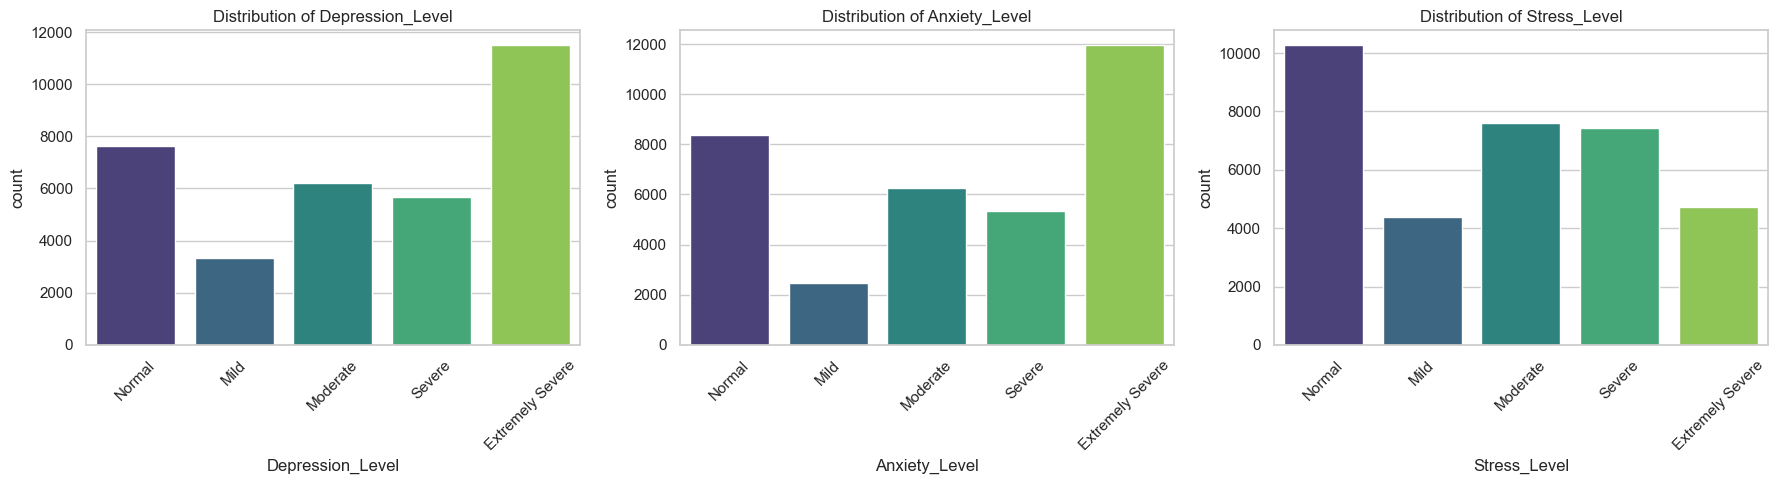

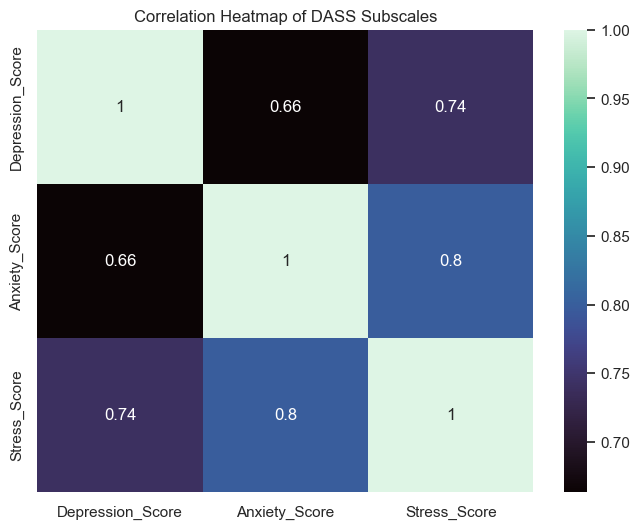

In [41]:
# Set visual style
sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Plot distributions
for i, col in enumerate(['Depression_Level', 'Anxiety_Level', 'Stress_Level']):
    sns.countplot(x=col, data=df, ax=axes[i], palette='viridis', 
                    order=['Normal', 'Mild', 'Moderate', 'Severe', 'Extremely Severe'])
    axes[i].set_title(f'Distribution of {col}')
    axes[i].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

# Correlation between the three scales
plt.figure(figsize=(8, 6))
sns.heatmap(df[['Depression_Score', 'Anxiety_Score', 'Stress_Score']].corr(), annot=True, cmap='mako')
plt.title('Correlation Heatmap of DASS Subscales')
plt.show()

In [42]:
df.to_csv('DASS_Cleaned_Features.csv', index=False)
print("Engineered dataset saved successfully!")

Engineered dataset saved successfully!
